# Failure clustering (Scania APS, PCA features)

This notebook is a **diagnostic step**: we explore whether the *minority class* (APS failures) contains **sub-types / modes**.

Why this matters:
- If failures form multiple clusters, naive oversampling may miss important structure.
- For diffusion-based augmentation, clustering can motivate **conditional generation** (generate each failure type separately) or at least help us validate diversity.

**Inputs**
- `../../data/processed/pca_aps_mean_failure_train_set.csv`
- `../../data/processed/pca_aps_mean_failure_test_set.csv`

**Outputs**
- Cluster labels for failure samples (in-memory) and plots/metrics (silhouette score).
- Optional saved figures (e.g., failure cluster scatter plots).

**You should run this after:** `01_DataExploration_Preprocessing_TUTORIAL.ipynb`


In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
# to display fully (non-truncated) data-frame
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # revert to 'last_expr' to get only last results

import sys # to make print statements work here

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
random_state = 42

## What to look for in the results

1. **Cluster sizes**  
   Are failure samples split roughly evenly, or is one cluster tiny?

2. **Silhouette score**  
   - Near **1**: clusters are well-separated.
   - Near **0**: clusters overlap (weak structure).
   - Negative: assignments may be wrong.

3. **Interpretation**  
   Clustering is not the final goal. It is a lens for understanding the *shape* of the minority class before we generate synthetic samples with diffusion.


### Check memory

In [2]:
import psutil
import gc
gc.collect()
psutil.virtual_memory()
print(list(psutil.virtual_memory())[0:2])

24

svmem(total=17179869184, available=3718103040, percent=78.4, used=6074236928, free=67207168, active=3666886656, inactive=3559276544, wired=2407350272)

[17179869184, 3718103040]


In [3]:
from sklearn.ensemble import RandomForestClassifier
import pickle

# # Load custom functions
# import GANS

# # For reloading after making changes
# import importlib
# importlib.reload(GANS)
# from GANS import *

## Load Dataset

This notebook expects PCA outputs from the preprocessing notebook.

If you do not have these files yet, run:
- `01_DataExploration_Preprocessing_TUTORIAL.ipynb`

The PCA files should include:
- `pc_0 ... pc_10` features
- `class` label (0/1)


In [4]:
# Load already engineered dataset from EDA section


data_train = pd.read_csv("../../data/processed/pca_aps_mean_failure_train_set.csv")
data_test =  pd.read_csv("../../data/processed/pca_aps_mean_failure_test_set.csv")


# data columns will be all other columns except class
data_cols = list(data_train.columns[data_train.columns != 'class' ])
label_cols = ['class']


print(data_cols)
print('# of data columns: ',len(data_cols))
print(data_train.shape)
print(data_test.shape)
data_train.head(3)

['pc_0', 'pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_6', 'pc_7', 'pc_8', 'pc_9', 'pc_10']
# of data columns:  11
(60000, 12)
(16000, 12)


,pc_0,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,class
0,-0.357653,0.149168,0.785559,0.107379,0.068720,-0.028512,0.128307,0.002902,0.073669,0.079233,-0.019663,0
1,-0.009868,0.178451,-0.153641,-0.106095,-0.115751,0.677376,0.038713,0.021226,-0.052543,-0.016909,-0.012898,0
2,0.036263,-0.202770,-0.164386,-0.072079,-0.131766,-0.043973,-0.051563,-0.000143,-0.000497,-0.034116,-0.000904,0


### Percentage of each class in the dataset
- 0 No failure
- 1 Failure

In [5]:
# 59000 with no failure (class 0)
# 1000 with failure (class 1)
print("Training:")
data_train['class'].value_counts()
data_train['class'].value_counts()/len(data_train)*100
print("\nTesting:")
data_test['class'].value_counts()
data_test['class'].value_counts()/len(data_test)*100

Training:


class
0    59000
1     1000
Name: count, dtype: int64

class
0    98.333333
1     1.666667
Name: count, dtype: float64


Testing:


class
0    15625
1      375
Name: count, dtype: int64

class
0    97.65625
1     2.34375
Name: count, dtype: float64

### Put columns in order of importance for xgboost scania (from that section)

In [6]:
#sorted_cols = xgb_important_features

sorted_cols = data_cols+label_cols
data_train = data_train[sorted_cols ].copy()


### Clustering the failure in Scania dataset - Creating two classes of failures using K-means

**Approach used here:** KMeans with `n_clusters=2`.

This is a simple starting point. In practice you may try:
- different `k`
- Gaussian Mixture Models
- HDBSCAN (density-based clustering)

We include silhouette score to quantify whether clustering is meaningful.


In [7]:
from sklearn.metrics import silhouette_score, silhouette_samples

In [8]:
# Add KMeans generated classes to failure data - see classification section for more details on this

import sklearn.cluster as cluster

train = data_train.loc[data_train['class']==1].copy()

algorithm = cluster.KMeans
args, kwds = (), {'n_clusters':2,
                  'random_state':random_state}

alg = algorithm(*args, **kwds)
labels = alg.fit_predict(train[data_cols])

print(pd.DataFrame([[np.sum(labels==i)] for i in np.unique(labels)],
                    columns=['count'], index=np.unique(labels) ) )

train_failure_w_classes = train.copy()
train_failure_w_classes['class'] = labels

silhouette_score(train[data_cols], labels)

# get silhouette for each cluster
sample_silhouette_values = silhouette_samples(train[data_cols], labels)

cluster_labels = labels
sil_lbl_dict = {}
for label in range(2):
    sil_lbl_dict[label] =(sample_silhouette_values[cluster_labels == label].mean())

print(sil_lbl_dict)

   count
0    616
1    384


0.2659480815728058

{0: np.float64(0.3536744037932198), 1: np.float64(0.12522043967755814)}


### Exploratory Data Analysis (EDA)

### Total Nulls in dataset (sum over rows, then over columns)

In [9]:
data_train.isnull().sum().sum()

np.int64(0)

### Check duplications in the dataset for all classes i.e. failure/no failure

In [10]:
# Duplicates? No

def check_duplicates(df):
    normal_duplicates = sum(df.loc[df['class']==0].duplicated())
    failure_duplicates = sum(df.loc[df['class']==1].duplicated())
    total_duplicates = normal_duplicates + failure_duplicates

    print( 'Normal duplicates', normal_duplicates )
    print( 'Failure duplicates', failure_duplicates )
    print( 'Total duplicates', total_duplicates )
    print( 'Failure duplicated', total_duplicates / len(df))

print("Trainning:")
check_duplicates(data_train)
print("\nTesting")
check_duplicates(data_test)

Trainning:


Normal duplicates 1
Failure duplicates 0
Total duplicates 1
Failure duplicated 1.6666666666666667e-05

Testing
Normal duplicates 0
Failure duplicates 0
Total duplicates 0
Failure duplicated 0.0


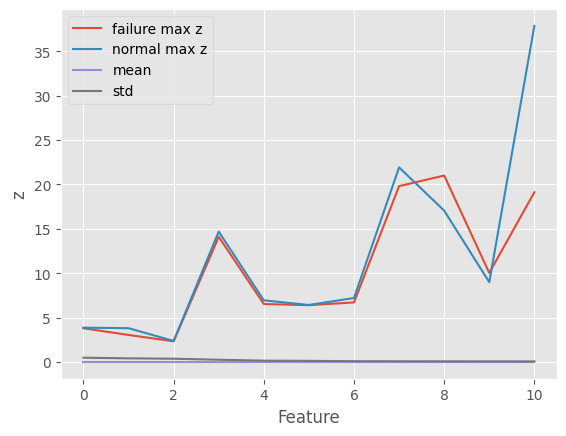

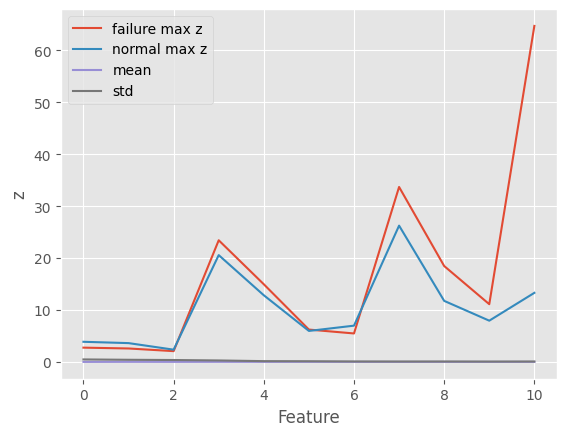

In [11]:
# There are outliers, 50-100 stdevs away from mean in several columns

def plot_data(df):
    plot_cols = data_cols
    # plt.plot( np.log10( data[ plot_cols ].abs().max().values ) )
    # plt.plot( data[ plot_cols ].abs().max().values / data[ plot_cols ].std().values / 10, label='max z/10' )
    plt.plot(df.loc[df['class']==1, plot_cols ].abs().max().values / df[plot_cols ].std().values, label='failure max z' )
    plt.plot(df.loc[df['class']==0, plot_cols ].abs().max().values / df[plot_cols ].std().values, label='normal max z' )
    plt.plot(df[ plot_cols ].mean().values, label='mean' )
    # plt.plot( data[ plot_cols ].abs().mean().values, label='abs mean' )
    plt.plot(df[ plot_cols ].std().values, label='std' )
    plt.xlabel('Feature')
    plt.ylabel('z')
    plt.legend()
    plt.show();

plot_data(data_train)
plot_data(data_test)

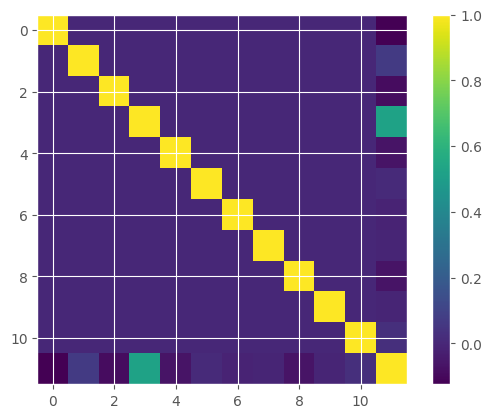

In [12]:
# Check Correlations
corr0 = data_train.corr()
plt.imshow(corr0)
plt.colorbar();

In [13]:
# Total nulls in dataset (sum over rows, then over columns)
data_train.isnull().sum().sum()
data_test.isnull().sum().sum()

np.int64(0)

np.int64(0)

<a id="Fig1"><h1>Figure 1: Data Distributions by Feature and Failure/Normal Class</h1></a><br>
<a href='#TOC'>Table of contents</a>

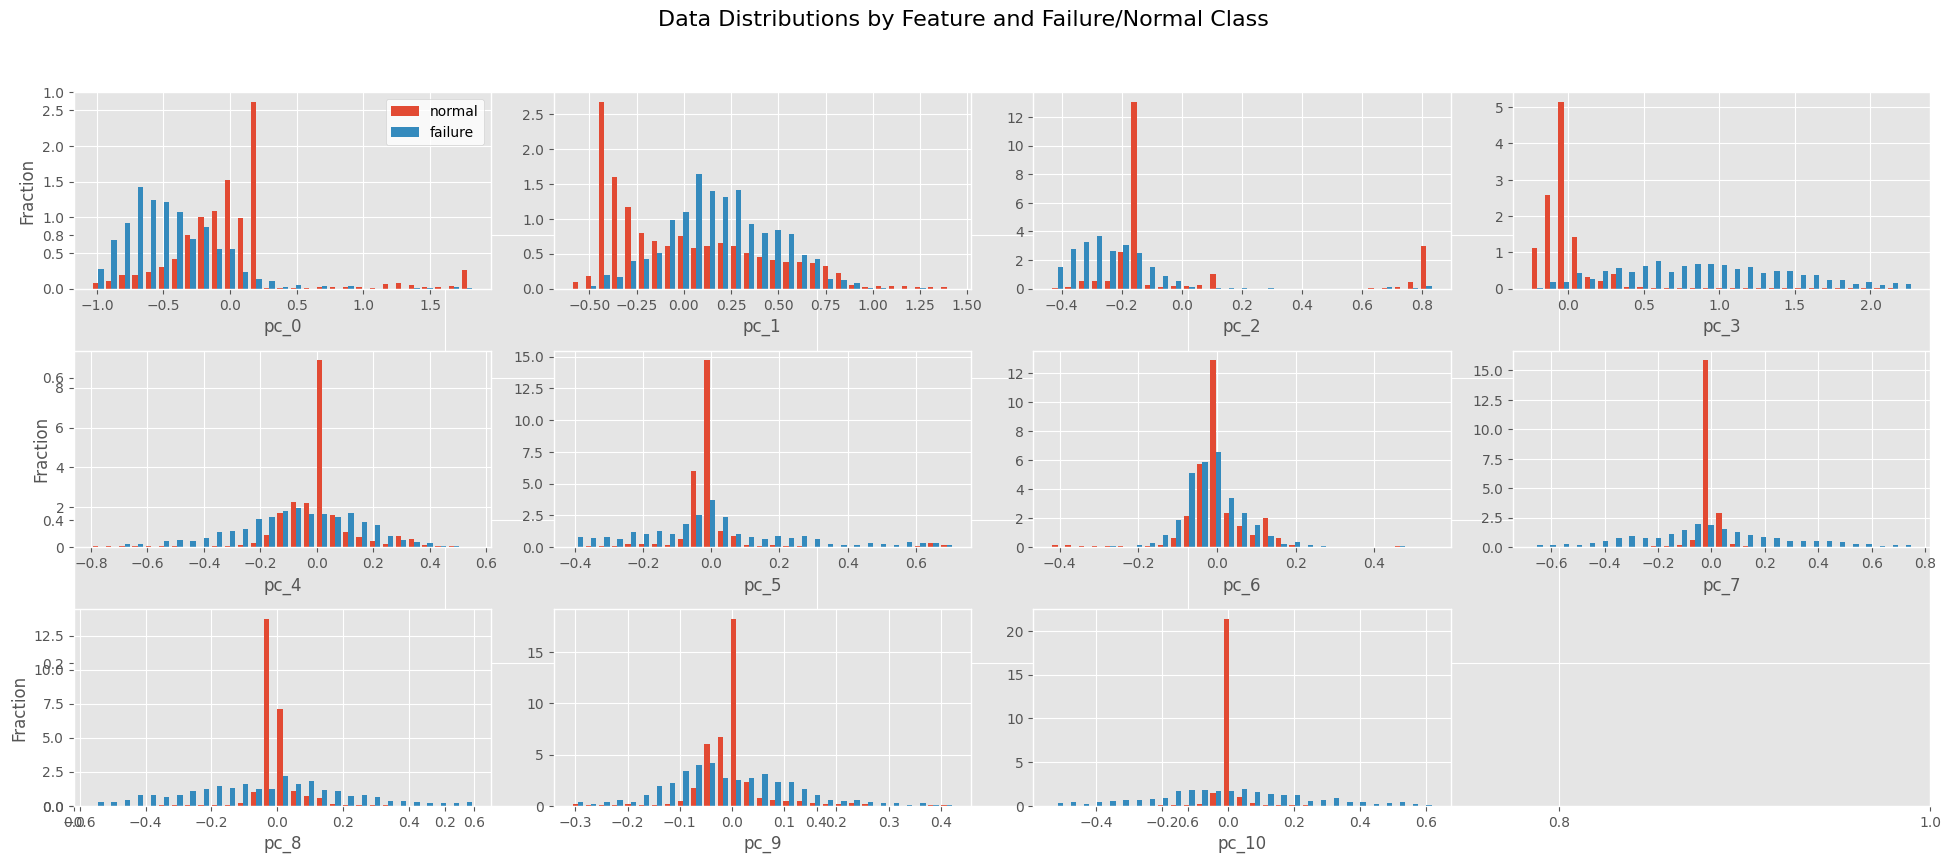

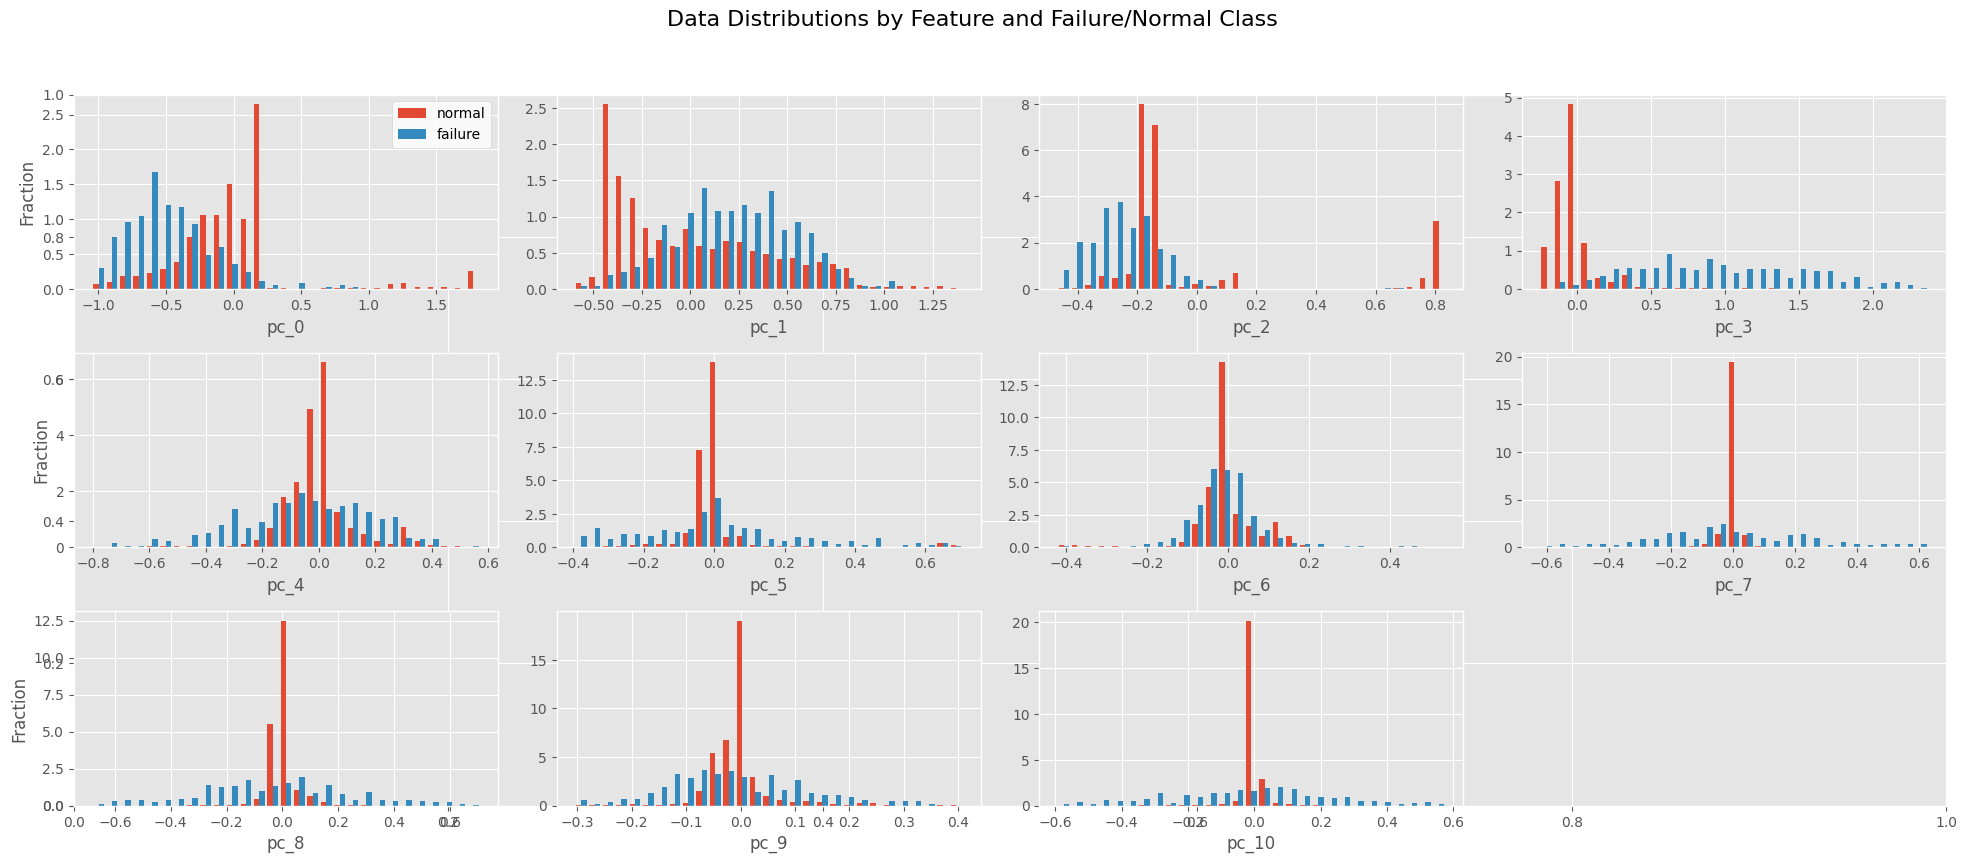

In [14]:
def plot_data_features(df, fig_name='Scanis_Engineered_Data_Distributions.png'):
    figures_dir = '../../outputs/figures'
    os.makedirs(figures_dir, exist_ok=True)
    # Plot the data by each feature
    axarr = [[]]*len(data_cols)
    columns = 4
    rows = int(np.ceil(len(data_cols)/columns))
    # f, fig = plt.subplots(figsize=(columns*3.5, rows*2) )
    f, fig = plt.subplots(figsize=(columns*5, rows*3) )

    f.suptitle('Data Distributions by Feature and Failure/Normal Class', size=16)

    for i, col in enumerate(data_cols[:]):
        axarr[i] = plt.subplot2grid( (int(rows), int(columns)), (int(i//columns), int(i%columns)) )
    #     print((int(i//columns), int(i%columns)))
        axarr[i].hist([df.loc[ df['class'] == 0, col ],
                       df.loc[ df['class'] == 1, col ] ],
                       label=['normal','failure'], bins=np.linspace( np.percentile(df[col],0.1),
                                                                    np.percentile(df[col],99.9), 30 ), density=True )
        axarr[i].set_xlabel(col, size=12)
    #     axarr[i].set_ylim([0,0.8])
    #     axarr[i].set_ylim([0,1.5])
        axarr[i].tick_params(axis='both', labelsize=10)
        if i == 0:
            legend = axarr[i].legend()
            legend.get_frame().set_facecolor('white')
        if i%4 != 0 :
            axarr[i].tick_params(axis='y', left='off', labelleft='off')
        else:
            axarr[i].set_ylabel('Fraction',size=12)

    plt.tight_layout(rect=[0,0,1,0.95]) # xmin, ymin, xmax, ymax
    plt.savefig(f"{figures_dir}/{fig_name}")
    plt.show()
    pass;
plot_data_features(data_train,fig_name='Scanis_Engineered_Train_Distributions.png')
plot_data_features(data_test,fig_name='Scanis_Engineered_Test_Distributions.png')

In [15]:
# Save engineered dataset as pickle for use in analysis
# pickle.dump(data_train, open('data/' + 'scania.train.engineered.pkl','wb'))
# pickle.dump(data_test, open('data/' + 'scania.test.engineered.pkl','wb'))
# Save as csv for human readability - much slower save
#data.to_csv('data/' + 'scania.engineered.csv.zip')

In [16]:
# Total nulls in dataset (sum over rows, then over columns)
data_train.isnull().sum().sum()
data_test.isnull().sum().sum()

np.int64(0)

np.int64(0)

### Clustering

In [17]:
# load clustering libraries

import sklearn.cluster as cluster
#!pip install hdbscan
import hdbscan

from sklearn.metrics import silhouette_score
from collections import Counter, OrderedDict
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import SpectralClustering

from sklearn.cluster import Birch
from sklearn.cluster import MeanShift

from sklearn.mixture import GaussianMixture

In [18]:

# Set up training set to consist of only failure data

train = data_train.loc[ data_train['class']==1 ].copy()

print( pd.DataFrame( [ [np.sum(train['class']==i)] for i in np.unique(train['class']) ], columns=['count'], index=np.unique(train['class']) ) )

# train = pd.get_dummies(train, columns=['Class'], prefix='Class')
label_cols = [ i for i in train.columns if 'class' in i ]
data_cols = [ i for i in train.columns if i not in label_cols ]
train_no_label = train[ data_cols ]


   count
1   1000


In [19]:
# Total nulls in dataset (sum over rows, then over columns)
train.isnull().sum().sum()
train_no_label.isnull().sum().sum()

np.int64(0)

np.int64(0)

In [20]:
%%time

# TSNE is an interesting method to map higher dimensional data into two dimensions
# http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

# Note TSNE map may not be what you might think:
# https://distill.pub/2016/misread-tsne/

# Create multiple projections to compare results from different random states

from sklearn.manifold import TSNE

train_no_label = train_no_label.apply(pd.to_numeric)
projections = [ TSNE(random_state=i, n_components=2).fit_transform(train_no_label) for i in range(3) ]
# projections = [ TSNE(random_state=i, n_iter=2000).fit_transform(train_no_label) for i in range(3) ]



CPU times: user 1min 5s, sys: 18 s, total: 1min 22s
Wall time: 13 s


In [21]:
import hdbscan
from sklearn.metrics import silhouette_score
from collections import Counter

spectral clustering 0.3798193063873423
Counter({np.int32(0): 908, np.int32(1): 92})
{0: np.float64(0.3909049014273842), 1: np.float64(0.2704093031660589)}
Birch 0.23920610591991848
Counter({np.int64(1): 678, np.int64(0): 322})


{0: np.float64(0.1394069221491249), 1: np.float64(0.2866033583892334)}


Meanshift 0.38555220243106647
Counter({np.int64(0): 989, np.int64(1): 11})
{0: np.float64(0.3850543154442315), 1: np.float64(0.43031676879285996)}
KMeans  0.2659480815728058
Counter({np.int32(0): 616, np.int32(1): 384})
{0: np.float64(0.3536744037932198), 1: np.float64(0.12522043967755814)}
Agglomerative 0.24096500689461384
Counter({np.int64(0): 718, np.int64(1): 282})
{0: np.float64(0.2765010111389484), 1: np.float64(0.1504868116909534)}


Agg. Ave 2 0.36748721937652534
Counter({np.int64(0): 911, np.int64(1): 89})
{0: np.float64(0.37705752622724026), 1: np.float64(0.26952598857875787)}
Agg. Single 2 0.4330702499758418
Counter({np.int64(0): 995, np.int64(1): 5})
{0: np.float64(0.4316828016837372), 1: np.float64(0.7091724601046571)}
Agg. Complete 2 0.2448532402552383
Counter({np.int64(1): 708, np.int64(0): 292})
{0: np.float64(0.13138121545988057), 1: np.float64(0.29165243692225024)}


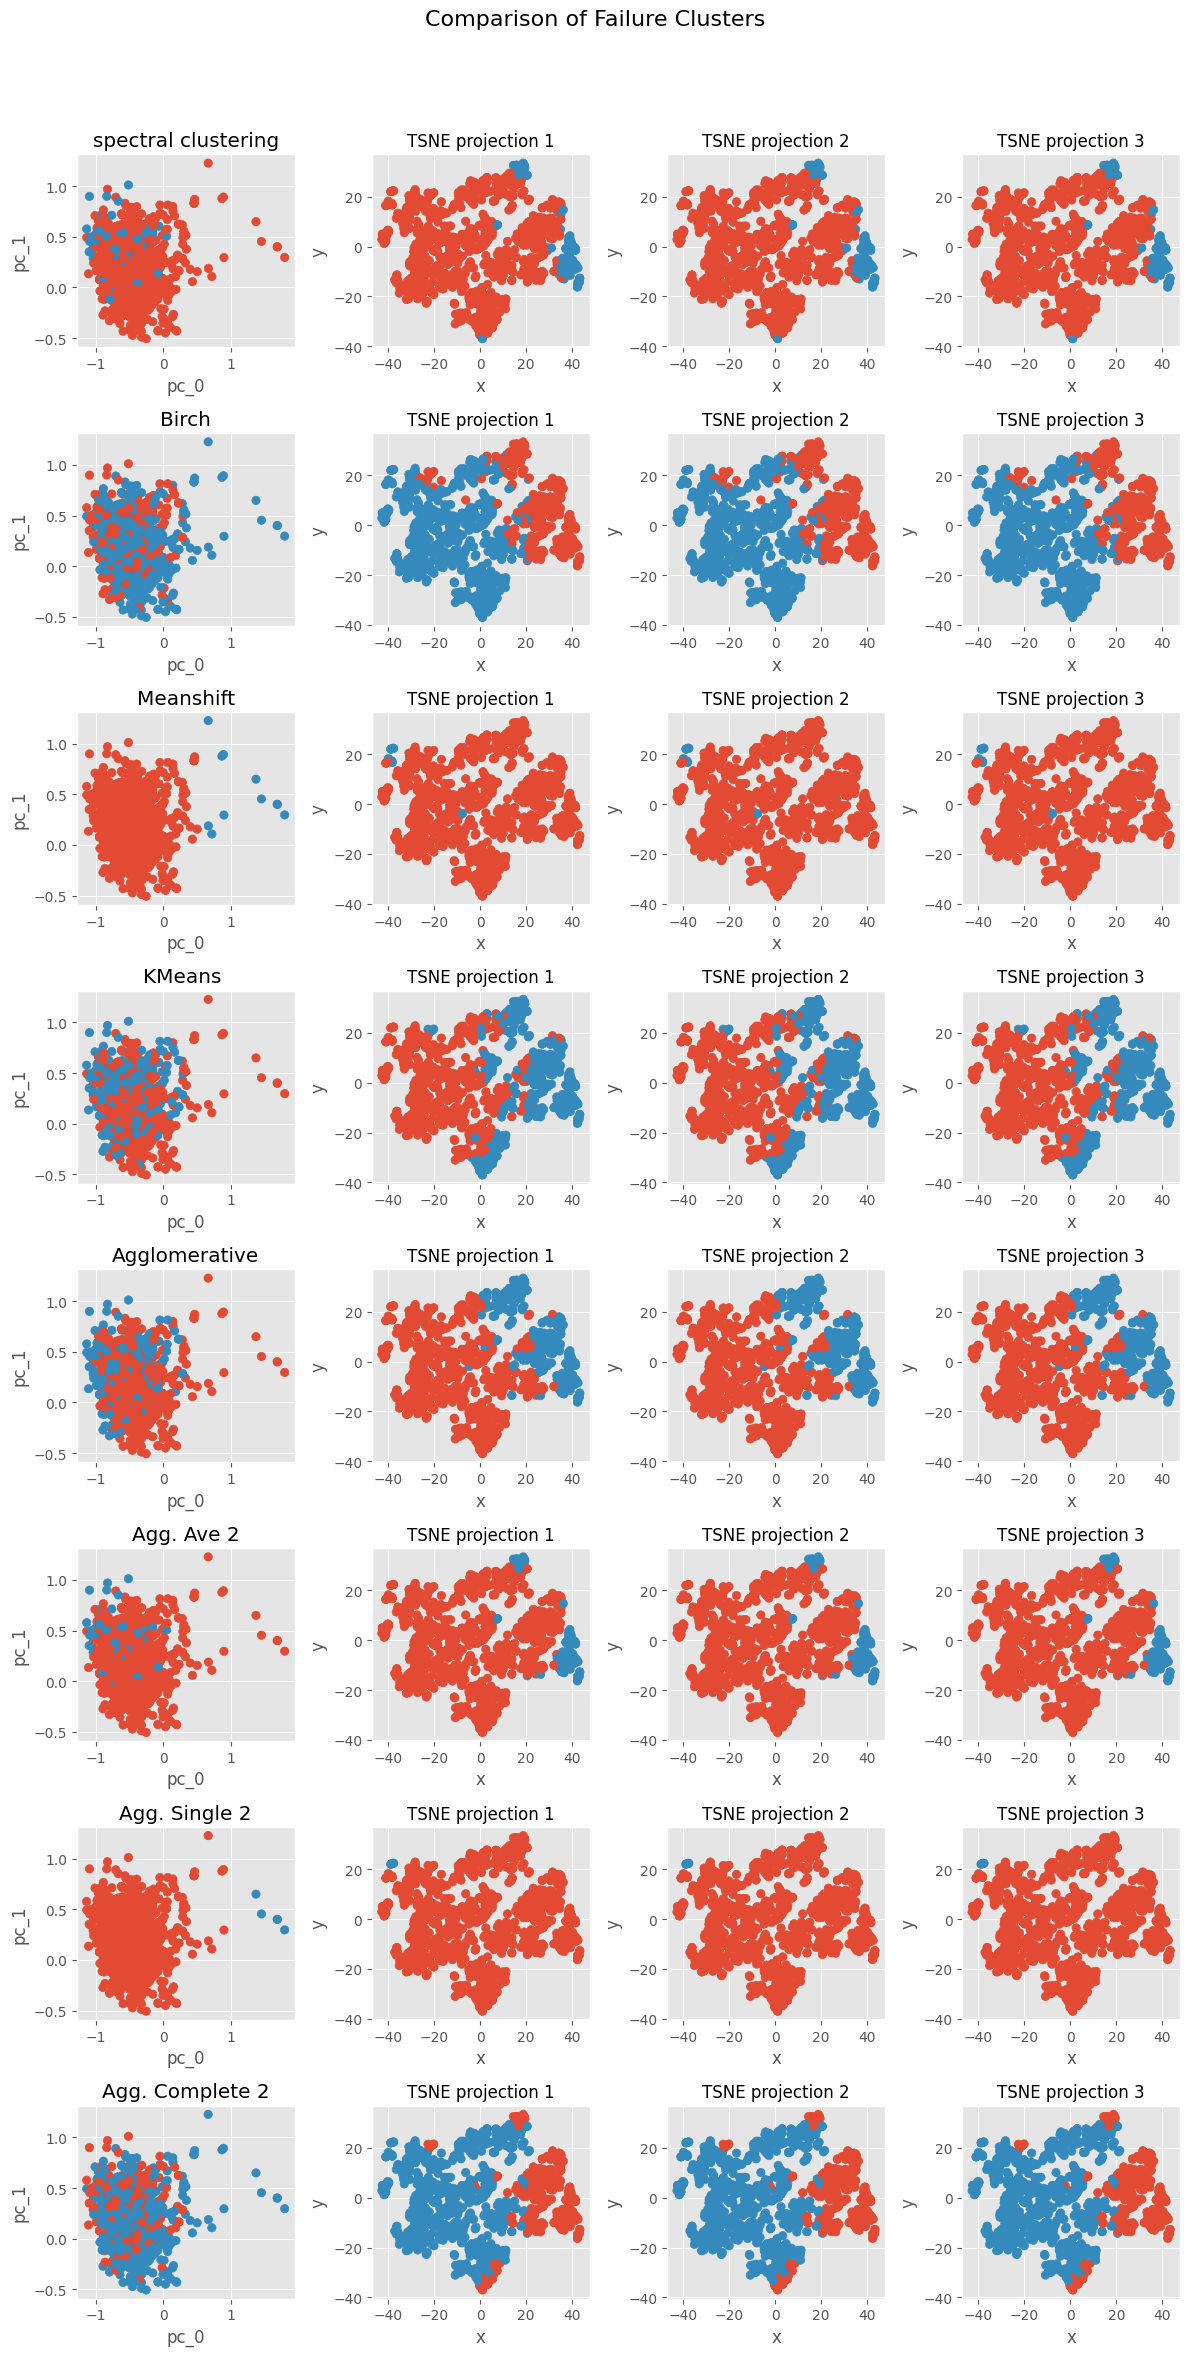

CPU times: user 9.1 s, sys: 1.62 s, total: 10.7 s
Wall time: 7.02 s


In [22]:
%%time


# Now we'll compare some different clustering algorithms
# https://github.com/scikit-learn-contrib/hdbscan/blob/master/docs/comparing_clustering_algorithms.rst

algorithms = [
    ['spectral clustering', SpectralClustering, (), {'n_clusters':2}],
    ['Birch', Birch,(), {'n_clusters':2}],
    ['Meanshift', MeanShift,(), {}],
    ['KMeans ', cluster.KMeans, (), {'n_clusters':2}],
    [ 'Agglomerative', cluster.AgglomerativeClustering, (), {'linkage': 'ward', 'n_clusters': 2} ],
    [ 'Agg. Ave 2', cluster.AgglomerativeClustering, (), {'linkage': 'average', 'n_clusters': 2} ],
    ['Agg. Single 2', cluster.AgglomerativeClustering, (), {'linkage': 'single', 'n_clusters': 2} ],
    [ 'Agg. Complete 2', cluster.AgglomerativeClustering, (), {'linkage': 'complete', 'n_clusters': 2} ],

]

rows = len(algorithms)
columns = 4
plt.figure(figsize=(columns*3, rows*3))

for i, [name, algorithm, args, kwds] in enumerate(algorithms):
#     print(i, name)
    alg = algorithm(*args, **kwds)
    # train_no_label.iloc[:,1:3]
    labels = alg.fit_predict(train_no_label)
    silhouette_avg = silhouette_score(train_no_label, labels)
    print(name, silhouette_avg)
    print(Counter(alg.labels_))

    # get silhouette values for each cluster
    # get silhouette for each cluster
    sample_silhouette_values = silhouette_samples(train_no_label, labels)

    cluster_labels = alg.labels_
    sil_lbl_dict = {}
    for label in range(2):
        sil_lbl_dict[label] =(sample_silhouette_values[cluster_labels == label].mean())

    print(sil_lbl_dict)
    print(''.join(["="]*10))

    colors = np.clip(labels,-1,9)
    colors = [ 'C'+str(i) if i>-1 else 'black' for i in colors ]

    plt.subplot(rows,columns,i*columns+1)
    plt.scatter(train_no_label[data_cols[0]], train_no_label[data_cols[1]], c=colors)
    plt.xlabel(data_cols[0]), plt.ylabel(data_cols[1])
    plt.title(name)

    for j in range(3):
        plt.subplot(rows,columns,i*columns+1+j+1)
        plt.scatter(*(projections[j].T), c=colors)
        plt.xlabel('x'), plt.ylabel('y')
        plt.title('TSNE projection '+str(j+1),size=12)
plt.suptitle('Comparison of Failure Clusters', size=16)
plt.tight_layout(rect=[0,0,1,0.95])
os.makedirs('../../outputs/figures', exist_ok=True)
plt.savefig('../../outputs/figures/Failure_Cluster_Diagram.png')
plt.show()

#Agg. Ave 2
#spectral clustering

In [23]:

# Now pick a set of labels and add to the dataset

#algorithm = cluster.KMeans
algorithm = cluster.AgglomerativeClustering
#args, kwds = (), {'n_clusters':2, 'random_state':random_state}
args, kwds = (),{'linkage': 'average', 'n_clusters': 2}
#args, kwds = (),{'linkage': 'single', 'n_clusters': 2}
labels = algorithm(*args, **kwds).fit_predict(train_no_label)
# labels = algorithm(*args, **kwds).fit_predict(projections[0])

print( pd.DataFrame( [ [np.sum(labels==i)] for i in np.unique(labels) ], columns=['count'], index=np.unique(labels) ) )

failure_w_classes = train.copy()
failure_w_classes['class'] = labels

silhouette_score(train_no_label, labels)

# get silhouette for each cluster
sample_silhouette_values = silhouette_samples(train_no_label, labels)

cluster_labels = alg.labels_
sil_lbl_dict = {}
for label in range(2):
    sil_lbl_dict[label] =(sample_silhouette_values[cluster_labels == label].mean())

print(sil_lbl_dict)

   count
0    911
1     89


0.36748721937652534

{0: np.float64(0.21404541082164905), 1: np.float64(0.4307711291194969)}


In [24]:

# Let's see which features are most useful for detecting differences between the clusters.
# Use a scikit-learn random forest here so the notebook runs cleanly without extra
# platform-specific runtime dependencies.

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=random_state,
    class_weight="balanced",
    n_jobs=-1,
)
rf.fit(failure_w_classes[data_cols], failure_w_classes["class"])

importances = sorted(
    zip(data_cols, rf.feature_importances_),
    key=lambda item: item[1],
    reverse=True,
)
print("Top eight features:", [[name, float(score)] for name, score in importances[:8]])


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Top eight features: [['pc_3', 0.4387149097225917], ['pc_4', 0.23831750834960116], ['pc_10', 0.08258305749015994], ['pc_2', 0.06624106056176975], ['pc_1', 0.05187062031503666], ['pc_7', 0.03158558448033905], ['pc_8', 0.026363901303108606], ['pc_9', 0.024414556919103304]]


In [25]:
len(data_cols) # including class

11